# Component 3: Exploratory Data Analysis (EDA) and Feature Selection

## Task 1: Data Cleaning & Preprocessing

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_excel("Online_Retail_2.xlsx")

# Display of the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (541909, 8)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
# Removing rows with missing values
df = df.dropna()

# Checking the new dataset shape
print("Dataset Shape after removing missing values:")
print(df.shape)

# Verify that no missing values present
print("\nRemaining Missing Values:")
print(df.isnull().sum())

Dataset Shape after removing missing values:
(406829, 8)

Remaining Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [6]:
# Check duplicate rows
print("Duplicate Rows Before Removing:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicate rows again
print("Duplicate Rows After Removing:", df.duplicated().sum())

# Dataset shape after removing duplicates
print("\nDataset Shape:")
print(df.shape)

Duplicate Rows Before Removing: 5225
Duplicate Rows After Removing: 0

Dataset Shape:
(401604, 8)


In [7]:
# Counting negative Quantity and UnitPrice

negative_quantity = (df['Quantity'] < 0).sum()
negative_price = (df['UnitPrice'] < 0).sum()

print("Negative Quantity:", negative_quantity)
print("Negative UnitPrice:", negative_price)

Negative Quantity: 8872
Negative UnitPrice: 0


In [8]:
# Remove rows with negative Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Checks the new dataset shape
print("Dataset Shape after removing anomalies:")
print(df.shape)

# Verify anomalies are removed
print("\nNegative Quantity:", (df['Quantity'] < 0).sum())
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())

Dataset Shape after removing anomalies:
(392692, 8)

Negative Quantity: 0
Negative UnitPrice: 0


In [9]:
# Feature Engineering

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.month_name()
df['Week'] = df['InvoiceDate'].dt.isocalendar().week
df['Day'] = df['InvoiceDate'].dt.day
df['Day_Name'] = df['InvoiceDate'].dt.day_name()

# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Month_Name,Week,Day,Day_Name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,December,48,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,December,48,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,December,48,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,December,48,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,December,48,1,Wednesday


In [10]:
# Creating Year-Week column
df['Year_Week'] = df['InvoiceDate'].dt.strftime('%Y-%U')

# Display first 5 rows
df[['InvoiceDate', 'Year_Week']].head()

,InvoiceDate,Year_Week
0,2010-12-01 08:26:00,2010-48
1,2010-12-01 08:26:00,2010-48
2,2010-12-01 08:26:00,2010-48
3,2010-12-01 08:26:00,2010-48
4,2010-12-01 08:26:00,2010-48


In [11]:
# Creating weekly shipment data for each product

weekly_shipments = (df.groupby(['StockCode', 'Year_Week'])['Quantity'].sum().reset_index())

# Display first 10 rows
weekly_shipments.head(10)

,StockCode,Year_Week,Quantity
0,10002,2010-48,61
1,10002,2010-49,127
2,10002,2010-50,36
3,10002,2011-01,72
4,10002,2011-02,35
5,10002,2011-03,80
6,10002,2011-04,4
7,10002,2011-05,147
8,10002,2011-07,13
9,10002,2011-08,36


In [12]:
# Creating a list of all weeks in the dataset
all_weeks = sorted(df['Year_Week'].unique())

# Display the first 10 weeks
print(all_weeks[:10])

['2010-48', '2010-49', '2010-50', '2010-51', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06']


In [13]:
# Get all products
all_products = df['StockCode'].unique()

# Create every possible Product-Week combination
full_index = pd.MultiIndex.from_product(
    [all_products, all_weeks],
    names=['StockCode', 'Year_Week']
)

# Convert into a DataFrame
full_df = pd.DataFrame(index=full_index).reset_index()

# Display first few rows
full_df.head()

,StockCode,Year_Week
0,85123A,2010-48
1,85123A,2010-49
2,85123A,2010-50
3,85123A,2010-51
4,85123A,2011-01


In [14]:
# Merge the complete Product-Week table with actual sales
weekly_shipments_complete = pd.merge(
    full_df,
    weekly_shipments,
    on=['StockCode', 'Year_Week'],
    how='left'
)

# Display first 10 rows
weekly_shipments_complete.head(10)

,StockCode,Year_Week,Quantity
0,85123A,2010-48,770.0
1,85123A,2010-49,1145.0
2,85123A,2010-50,1464.0
3,85123A,2010-51,232.0
4,85123A,2011-01,875.0
5,85123A,2011-02,3397.0
6,85123A,2011-03,585.0
7,85123A,2011-04,453.0
8,85123A,2011-05,665.0
9,85123A,2011-06,540.0


In [15]:
# Fill missing weekly quantities with 0
weekly_shipments_complete['Quantity'] = weekly_shipments_complete['Quantity'].fillna(0)

# Convert Quantity to integer
weekly_shipments_complete['Quantity'] = weekly_shipments_complete['Quantity'].astype(int)

# Display first 10 rows
weekly_shipments_complete.head(10)

,StockCode,Year_Week,Quantity
0,85123A,2010-48,770
1,85123A,2010-49,1145
2,85123A,2010-50,1464
3,85123A,2010-51,232
4,85123A,2011-01,875
5,85123A,2011-02,3397
6,85123A,2011-03,585
7,85123A,2011-04,453
8,85123A,2011-05,665
9,85123A,2011-06,540


In [16]:
# Check if any missing Quantity values remain
print("Missing Quantity values:", weekly_shipments_complete['Quantity'].isnull().sum())

# Display dataset size
print("Final Dataset Shape:")
print(weekly_shipments_complete.shape)

Missing Quantity values: 0
Final Dataset Shape:
(194245, 3)


In [17]:
# Saving the cleaned weekly shipment dataset to Excel
weekly_shipments_complete.to_excel(
    "Cleaned_Weekly_Shipments.xlsx",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Task 2: Exploratory Data Analysis (EDA)

### 1. Univariate Analysis

Univariate analysis examines one variable at a time to understand its distribution, central tendency, spread, and overall characteristics.

In [18]:
# Summary Statistics

print("Summary Statistics for Numerical Features")

df[['Quantity', 'UnitPrice']].describe()

Summary Statistics for Numerical Features


,Quantity,UnitPrice
count,392692.000000,392692.000000
mean,13.119702,3.125914
std,180.492832,22.241836
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


### Mean, Median and Mode

In [19]:
# Mean
print("Mean")
print(df[['Quantity', 'UnitPrice']].mean())

# Median
print("\nMedian")
print(df[['Quantity', 'UnitPrice']].median())

# Mode
print("\nMode")
print(df[['Quantity', 'UnitPrice']].mode())

Mean
Quantity     13.119702
UnitPrice     3.125914
dtype: float64

Median
Quantity     6.00
UnitPrice    1.95
dtype: float64

Mode
   Quantity  UnitPrice
0         1       1.25


### Histogram of Quantity

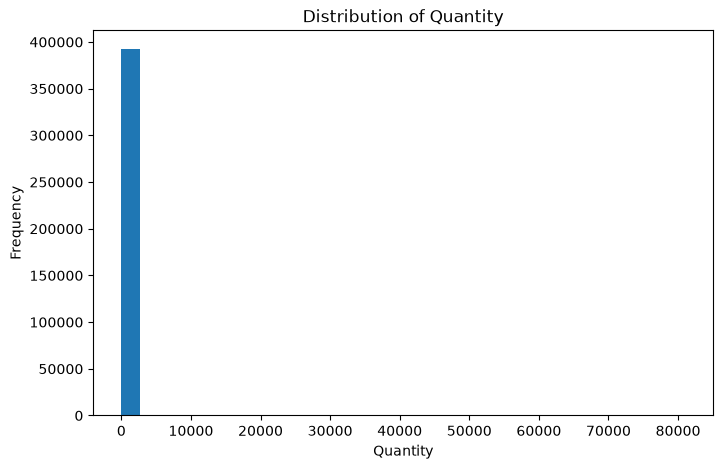

In [20]:
# Histogram for Quantity

plt.figure(figsize=(8,5))

plt.hist(df['Quantity'], bins=30)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

### Density Plot of Quantity

A density plot provides a smooth representation of the distribution of the Quantity feature.

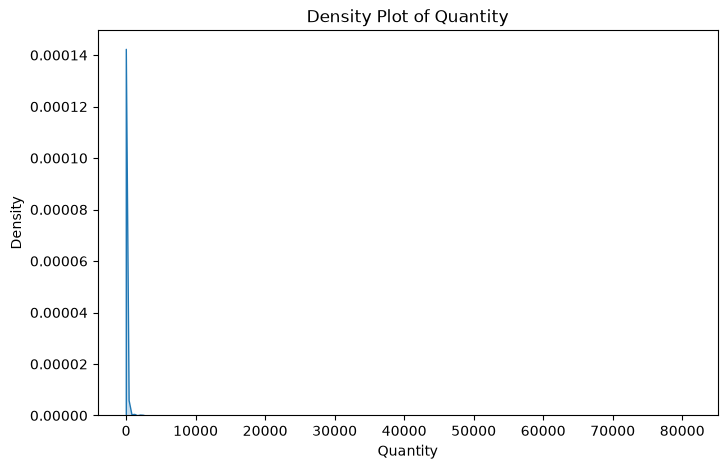

In [21]:
# Density Plot for Quantity

plt.figure(figsize=(8,5))

sns.kdeplot(df['Quantity'], fill=True)

plt.title("Density Plot of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Density")

plt.show()

### Improved Histogram of Quantity (Zoomed View)

To better visualize the distribution of most transactions . This does not modify the data; it only improves visualization by reducing the effect of extreme outliers.

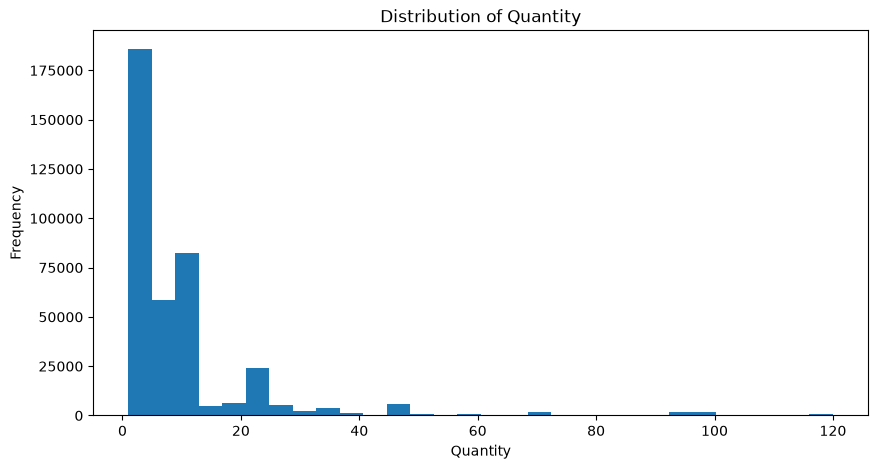

In [22]:
# Improved Histogram (Zoomed)

plt.figure(figsize=(10,5))

limit = df['Quantity'].quantile(0.99)

plt.hist(df[df['Quantity'] <= limit]['Quantity'], bins=30)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

### Histogram of Unit Price

The histogram below shows the distribution of product prices in the dataset.

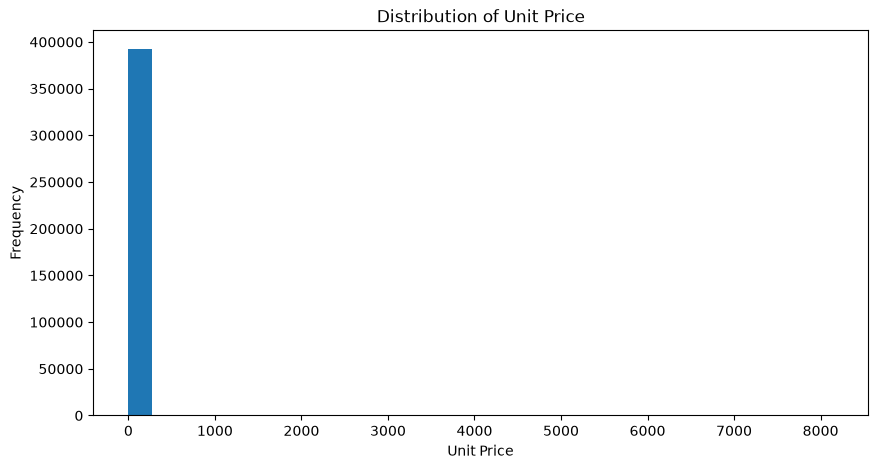

In [23]:
# Histogram for UnitPrice

plt.figure(figsize=(10,5))

plt.hist(df['UnitPrice'], bins=30)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

### Improved Histogram of Unit Price (Zoomed View)

To better visualize the distribution of most product prices. This improves readability while preserving the original data.

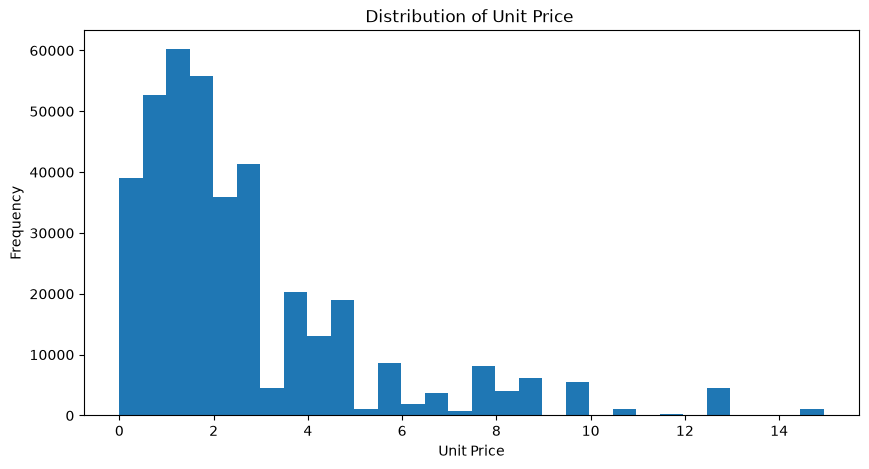

In [24]:
# Improved Histogram for UnitPrice

plt.figure(figsize=(10,5))

limit = df['UnitPrice'].quantile(0.99)

plt.hist(df[df['UnitPrice'] <= limit]['UnitPrice'], bins=30)

plt.title("Distribution of Unit Price ")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

### Density Plot of Unit Price

A density plot provides a smooth representation of the distribution of the UnitPrice feature.

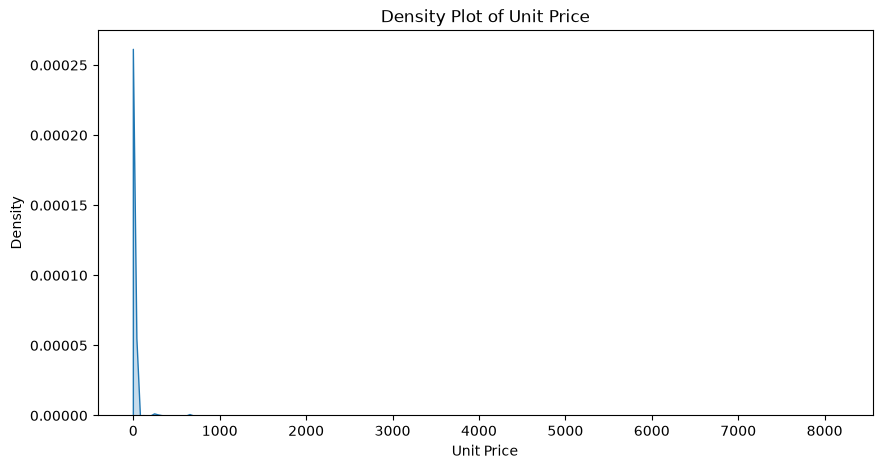

In [25]:
# Density Plot for UnitPrice

plt.figure(figsize=(10,5))

sns.kdeplot(df['UnitPrice'], fill=True)

plt.title("Density Plot of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")

plt.show()

### Bar Chart of Top 10 Countries

The following bar chart shows the top 10 countries based on the number of transactions.

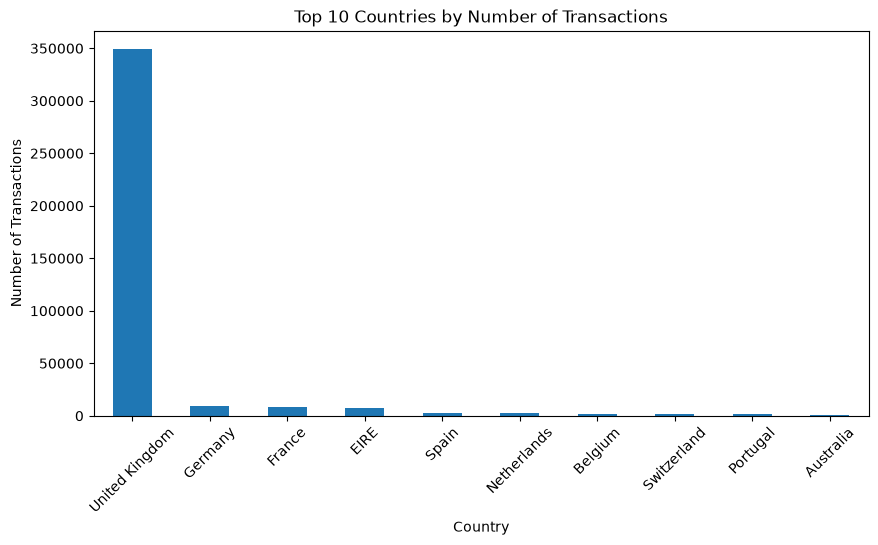

In [26]:
# Top 10 Countries by Number of Transactions

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

### Bar Chart of Top Countries (Excluding United Kingdom)

Since the United Kingdom contributes the majority of transactions, it is excluded from this visualization to better compare the remaining countries.

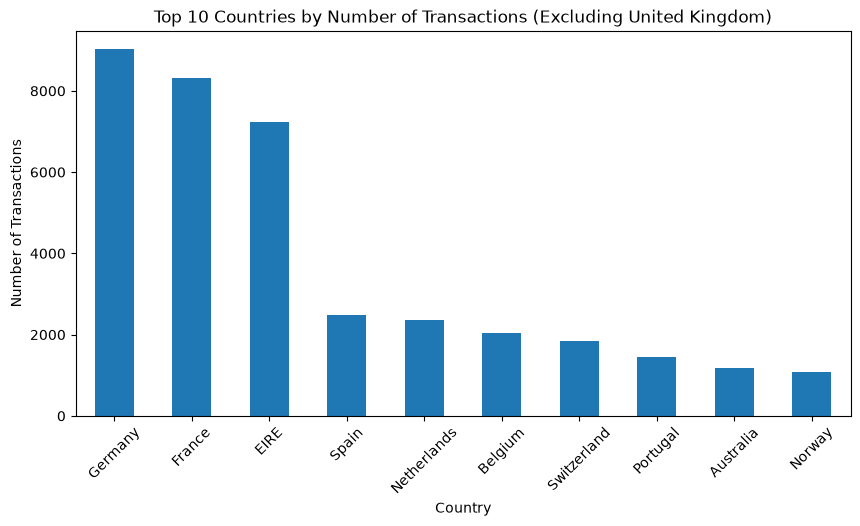

In [27]:
# Top Countries Excluding United Kingdom

country_counts = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

country_counts.plot(kind='bar')

plt.title("Top 10 Countries by Number of Transactions (Excluding United Kingdom)")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

### Pie Chart of Top 10 Countries

The following pie chart shows the proportion of transactions contributed by the top 10 countries.

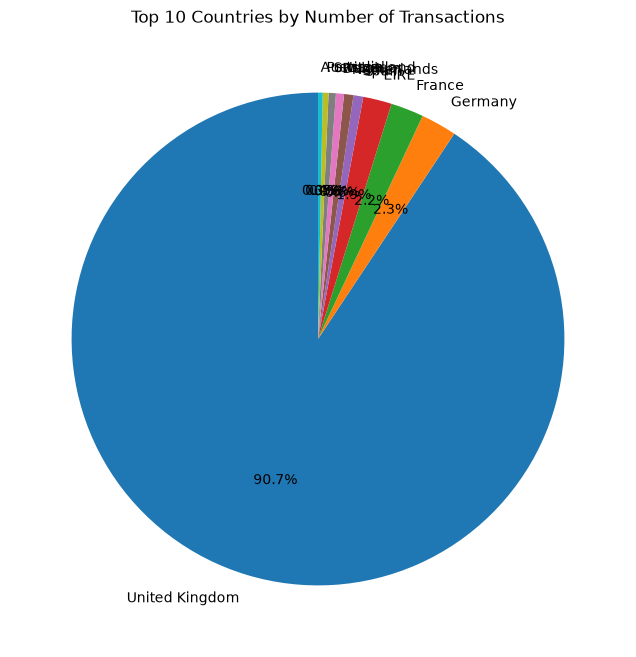

In [28]:
# Pie Chart of Top 10 Countries

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_countries,
    labels=top_countries.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Countries by Number of Transactions")

plt.show()

### Pie Chart of Top Countries (Excluding United Kingdom)

Since the United Kingdom accounts for the majority of transactions, it is excluded to better visualize the proportion of transactions from the remaining countries.

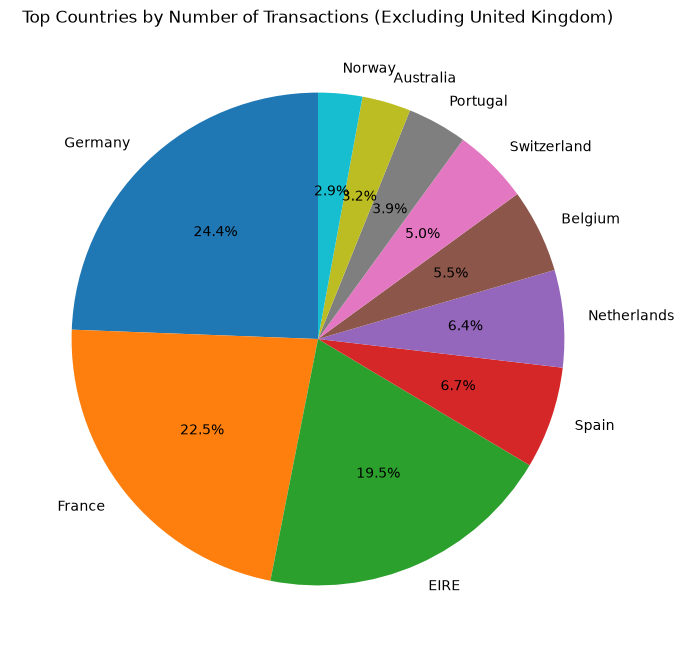

In [29]:
# Pie Chart excluding United Kingdom

country_counts = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    country_counts,
    labels=country_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top Countries by Number of Transactions (Excluding United Kingdom)")

plt.show()


## 2. Bivariate Analysis

Bivariate analysis examines the relationship between two variables. It helps identify correlations, patterns, and dependencies between numerical features.

### Correlation Matrix

In [30]:
# Correlation Matrix

correlation = df[['Quantity', 'UnitPrice']].corr()

print("Correlation Matrix:")
correlation

Correlation Matrix:


,Quantity,UnitPrice
Quantity,1.000000,-0.004578
UnitPrice,-0.004578,1.000000


### Correlation Heatmap

The heatmap provides a visual representation of the correlation between numerical features. Darker colors indicate stronger relationships, while lighter colors indicate weaker relationships.

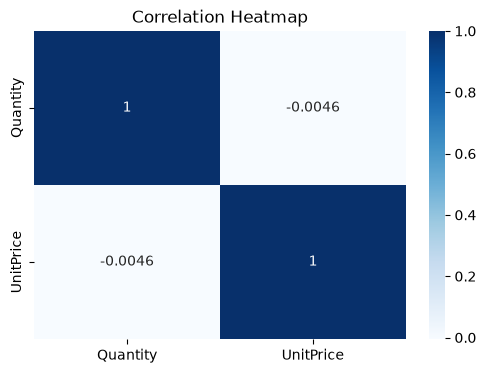

In [31]:
# Correlation Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

### Scatter Plot: Quantity vs Unit Price

A scatter plot is used to visualize the relationship between Quantity and UnitPrice.

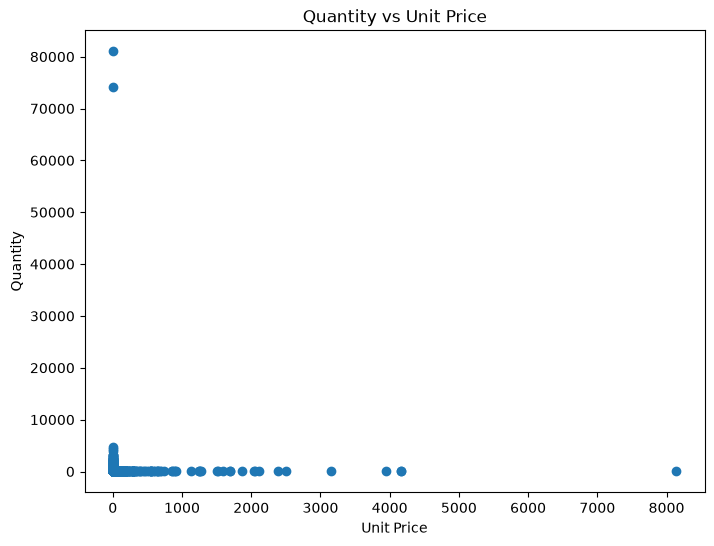

In [32]:
# Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(
    df['UnitPrice'],
    df['Quantity'], 
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.show()

### Box Plot of Quantity

The box plot is used to identify the spread of Quantity values.

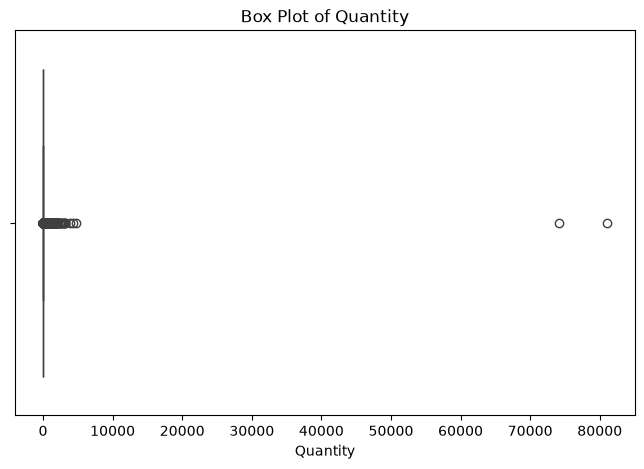

In [33]:
# Box Plot for Quantity

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Quantity'])

plt.title("Box Plot of Quantity")

plt.show()

### Box Plot of Unit Price

The box plot is used to identify the spread of UnitPrice values.

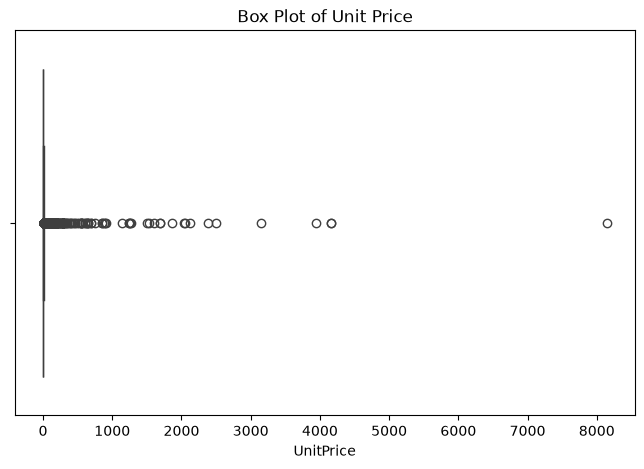

In [34]:
# Box Plot for UnitPrice

plt.figure(figsize=(8,5))

sns.boxplot(x=df['UnitPrice'])

plt.title("Box Plot of Unit Price")

plt.show()

### Pair Plot

A pair plot provides a combined visualization of the distributions of numerical variables and the relationships between them.

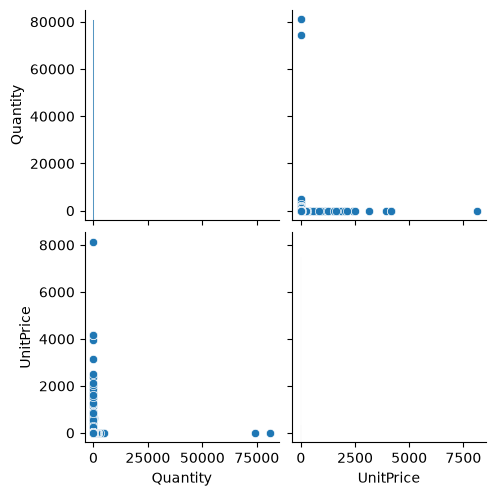

In [35]:
# Pair Plot

sns.pairplot(df[['Quantity', 'UnitPrice']])

plt.show()

## 3. Multivariate Analysis

Multivariate analysis examines multiple variables simultaneously to identify hidden patterns, relationships, and structures in the dataset.

### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is used to reduce the dimensionality of numerical data while preserving as much information as possible. It helps visualize patterns and simplifies complex datasets.

In [36]:
# Import PCA and StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Standardizing the Data

Before applying PCA, the numerical features are standardized so that each feature contributes equally to the analysis.

In [37]:
# Select numerical features

features = df[['Quantity', 'UnitPrice']]

# Standardize the features

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Display the first 5 rows

scaled_features[:5]

array([[-0.03944595, -0.02589331],
       [-0.03944595,  0.01187341],
       [-0.02836516, -0.01690123],
       [-0.03944595,  0.01187341],
       [-0.03944595,  0.01187341]])

### Applying Principal Component Analysis (PCA)

PCA transforms the standardized numerical features into principal components.

In [38]:
# Apply PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

# Create a DataFrame

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

# Display first 5 rows

pca_df.head()

,PC1,PC2
0,0.009583,-0.046202
1,0.036288,-0.019497
2,0.008106,-0.032008
3,0.036288,-0.019497
4,0.036288,-0.019497


### PCA Scatter Plot

The scatter plot below visualizes the first two principal components obtained from the numerical features. It helps identify patterns and the overall distribution of the data.

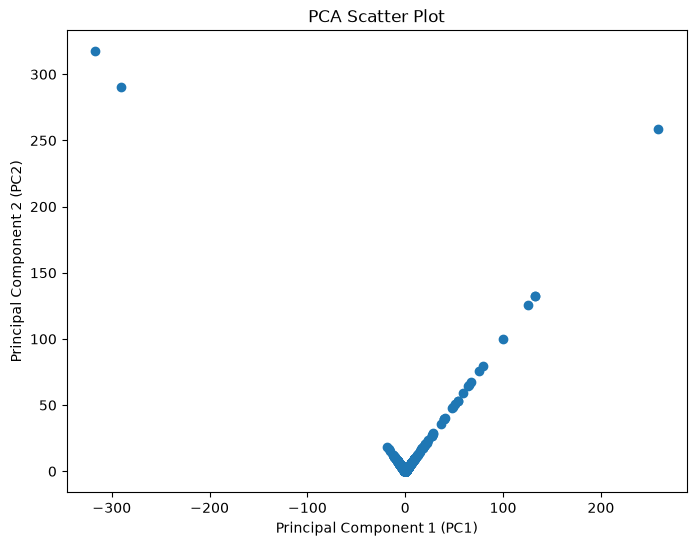

In [39]:
# PCA Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
)

plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.show()

### Explained Variance Ratio

The explained variance ratio indicates how much of the dataset's total variance is captured by each principal component.

In [40]:
# Explained Variance Ratio

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.50228916 0.49771084]


### Explained Variance Bar Chart

The following bar chart shows the percentage of variance explained by each principal component.

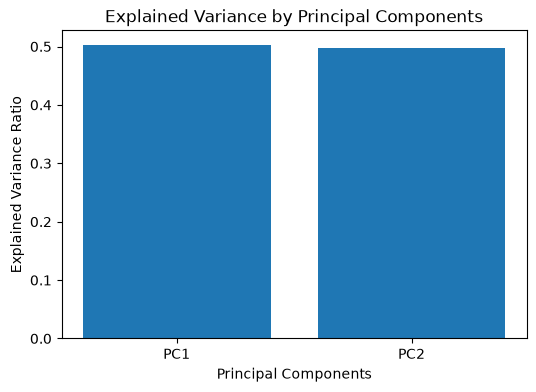

In [41]:
# Explained Variance Bar Chart

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.bar(
    ['PC1', 'PC2'],
    explained_variance
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.show()

### 3D Scatter Plot

The 3D scatter plot provides a three-dimensional visualization of the principal components. It helps observe the distribution of observations from different viewing angles.

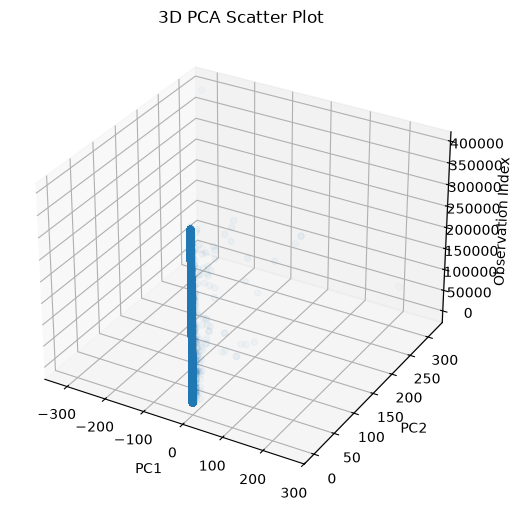

In [42]:
# 3D Scatter Plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    range(len(pca_df)),
    alpha=0.2
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("Observation Index")

ax.set_title("3D PCA Scatter Plot")

plt.show()

# Time Series Analysis

Time series analysis helps identify trends, seasonality, and irregular patterns in weekly sales data. These insights can be used to understand sales behavior over time and support future forecasting.

### Weekly Sales Data

The weekly sales data is created by summing the total quantity sold across all products for each week.

In [43]:
# Create Weekly Sales Data

weekly_sales = (
    weekly_shipments_complete
    .groupby('Year_Week')['Quantity']
    .sum()
    .reset_index()
)

weekly_sales.head()

,Year_Week,Quantity
0,2010-48,66989
1,2010-49,106567
2,2010-50,103043
3,2010-51,34449
4,2011-01,61975


### Weekly Sales Over Time

The following line chart visualizes the total weekly sales quantity over time. It helps identify trends, fluctuations, and unusual changes in sales.

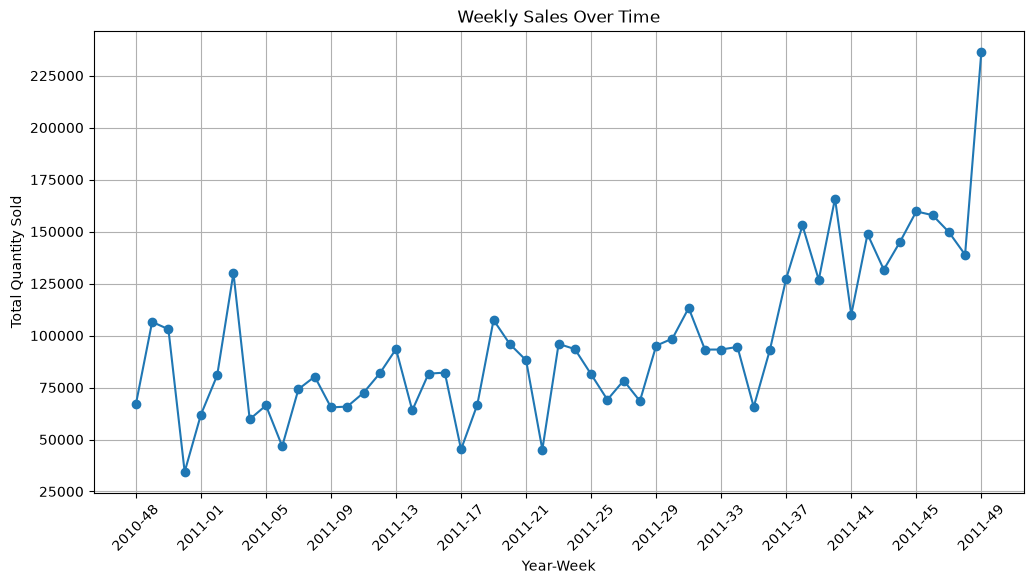

In [44]:
# Plot Weekly Sales Over Time

plt.figure(figsize=(12,6))

plt.plot(
    weekly_sales['Year_Week'],
    weekly_sales['Quantity'],
    marker='o'
)

plt.title("Weekly Sales Over Time")
plt.xlabel("Year-Week")
plt.ylabel("Total Quantity Sold")

# Show fewer x-axis labels for better readability
plt.xticks(rotation=45)
plt.xticks(weekly_sales.index[::4], weekly_sales['Year_Week'][::4])

plt.grid(True)

plt.show()

### Rolling Average of Weekly Sales

A rolling average smooths short term fluctuations in sales data, making it easier to identify long term trends.

In [45]:
# Calculate 4-Week Rolling Average

weekly_sales['Rolling_Avg'] = weekly_sales['Quantity'].rolling(window=4).mean()

weekly_sales.head()

,Year_Week,Quantity,Rolling_Avg
0,2010-48,66989,NaN
1,2010-49,106567,NaN
2,2010-50,103043,NaN
3,2010-51,34449,77762.0
4,2011-01,61975,76508.5


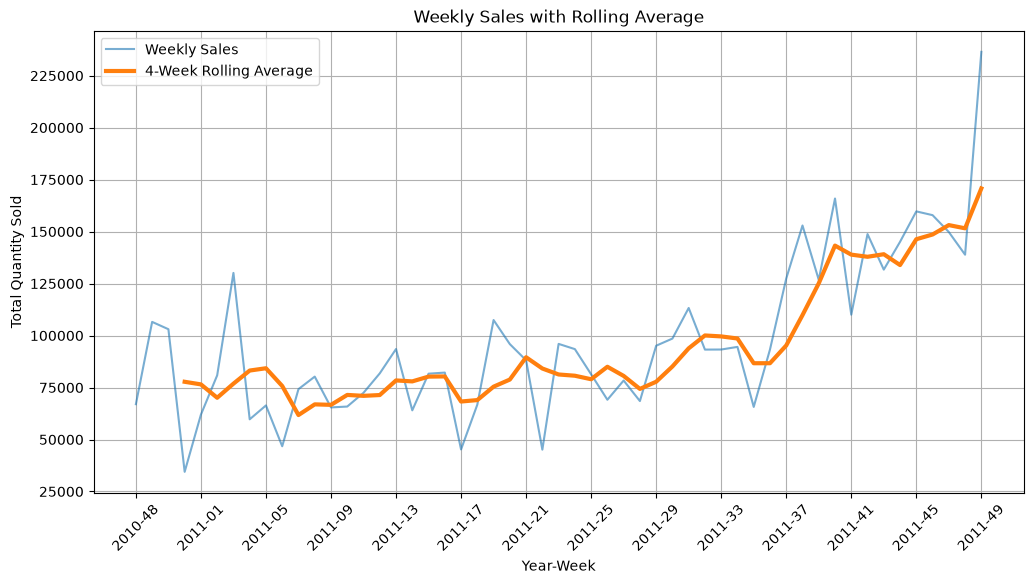

In [46]:
# Plot Weekly Sales with Rolling Average

plt.figure(figsize=(12,6))

plt.plot(
    weekly_sales['Year_Week'],
    weekly_sales['Quantity'],
    label='Weekly Sales',
    alpha=0.6
)

plt.plot(
    weekly_sales['Year_Week'],
    weekly_sales['Rolling_Avg'],
    linewidth=3,
    label='4-Week Rolling Average'
)

plt.title("Weekly Sales with Rolling Average")
plt.xlabel("Year-Week")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)
plt.xticks(weekly_sales.index[::4], weekly_sales['Year_Week'][::4])

plt.legend()
plt.grid(True)

plt.show()

### Seasonal Decomposition

Seasonal decomposition separates the sales time series into trend to understand better sales patterns over time.

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [48]:
# Convert Year_Week to datetime

weekly_sales['Date'] = pd.to_datetime(
    weekly_sales['Year_Week'] + '-1',
    format='%G-%V-%u'
)

weekly_sales = weekly_sales.set_index('Date')

weekly_sales.head()

,Year_Week,Quantity,Rolling_Avg
Date,,,
2010-11-29,2010-48,66989,NaN
2010-12-06,2010-49,106567,NaN
2010-12-13,2010-50,103043,NaN
2010-12-20,2010-51,34449,77762.0
2011-01-03,2011-01,61975,76508.5


### Seasonal Decomposition

Seasonal decomposition separates the weekly sales data into trend, seasonal, and residual components. This helps identify long-term trends, recurring seasonal patterns, and random fluctuations.

In [49]:
# Perform Seasonal Decomposition

decomposition = seasonal_decompose(
    weekly_sales['Quantity'],
    model='additive',
    period=4
)

### Seasonal Decomposition Components

The following plots display the original weekly sales data along with its trend, seasonal, and residual components obtained through additive seasonal decomposition.

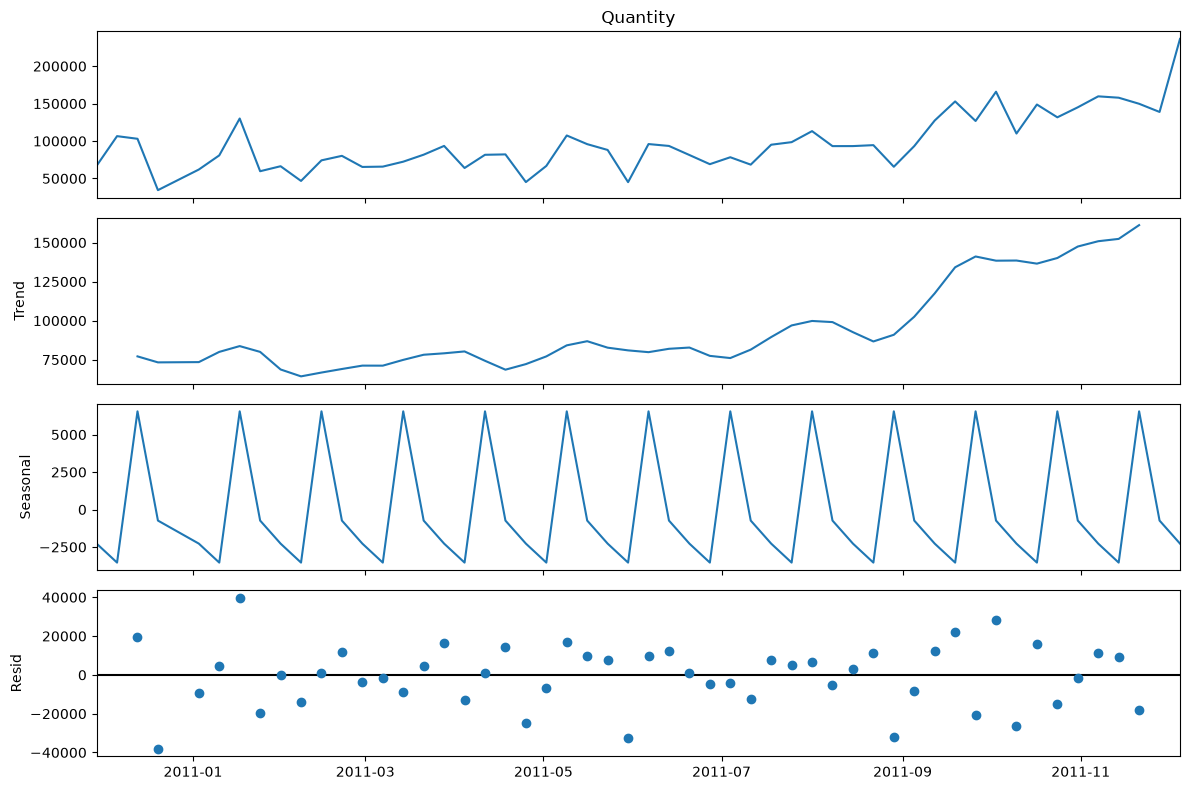

In [50]:
# Plot Seasonal Decomposition

plt.rcParams['figure.figsize'] = (12, 8)

decomposition.plot()

plt.show()

## Feature Selection

Feature selection helps identify the most relevant variables for forecasting sales while removing unnecessary or less informative features.

In [51]:
# Selected Features for Sales Forecasting

selected_features = [
    'StockCode',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'Country'
]

print("Selected Features:")
print(selected_features)

Selected Features:
['StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Country']


**Insight:**

The selected features are relevant for forecasting sales. Quantity represents the target variable, InvoiceDate provides the time dimension, StockCode identifies products, UnitPrice reflects pricing, and Country provides geographical information that may influence sales patterns.

## Stationarity Check

The Augmented Dickey-Fuller (ADF) test is used to determine whether the weekly sales time series is stationary. A p-value less than 0.05 indicates that the series is stationary.

In [52]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(weekly_sales['Quantity'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("\nThe time series is stationary.")
else:
    print("\nThe time series is not stationary.")

ADF Statistic: 0.7775194205869314
p-value: 0.9912644851142955

The time series is not stationary.


### First Differencing

Since the ADF test indicated that the series is non-stationary, first differencing was applied to reduce the trend and stabilize the mean of the time series.

In [53]:
# Apply First Differencing

weekly_sales['Quantity_Diff'] = weekly_sales['Quantity'].diff()

weekly_sales[['Quantity', 'Quantity_Diff']].head()

,Quantity,Quantity_Diff
Date,,
2010-11-29,66989,NaN
2010-12-06,106567,39578.0
2010-12-13,103043,-3524.0
2010-12-20,34449,-68594.0
2011-01-03,61975,27526.0


In [54]:
# ADF Test after First Differencing

adf_diff = adfuller(weekly_sales['Quantity_Diff'].dropna())

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

if adf_diff[1] < 0.05:
    print("\nThe differenced series is stationary.")
else:
    print("\nThe differenced series is still not stationary.")

ADF Statistic: -7.583130974507837
p-value: 2.6493363708312716e-11

The differenced series is stationary.


### Insight

The original weekly sales time series was found to be non-stationary based on the ADF test (p-value > 0.05). After applying first differencing, the p-value became less than 0.05, indicating that the transformed series is stationary. Therefore, the data is now suitable for time series forecasting models that require stationarity.

# Final Conclusion

The dataset was successfully cleaned and preprocessed by handling missing values, duplicate records, and invalid observations. Exploratory Data Analysis (EDA) provided insights into the distribution of numerical variables, relationships between features, and sales patterns across different countries.

Principal Component Analysis (PCA) was used to summarize the numerical features and visualize the overall data structure. Time series analysis identified sales trends and seasonal behavior, while the Augmented Dickey-Fuller (ADF) test confirmed that first differencing transformed the weekly sales series into a stationary time series suitable for forecasting.

Overall, the prepared dataset is clean, well-structured, and ready for predictive modeling in the next component.